# Agent-Based Model: Student Housing & Loneliness

This model simulates student housing choices between studios and shared housing, and tracks how housing allocation affects loneliness, mismatch, rents, supply, and public policy costs. **To be continued**

## Research focus
- How do students choose between studios and shared housing?
- How does this choice affect loneliness?
- How do different policy scenarios influence student loneliness, as well as housing demand and supply?

### 1. Imports

In [185]:
from __future__ import annotations

from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mesa

from mesa.datacollection import DataCollector

### 2. Student income generation

In [186]:
# Source: database.eurostudent.eu
INCOME_DECILE_MAX_VALUES = [
    780, 1000, 1150, 1301.67, 1461.67,
    1618.33, 1810, 2055, 2425, 6556.67
]

INCOME_DECILE_MEAN_VALUES = [
    567.24, 893.87, 1074.81, 1228.65, 1384.45,
    1537.44, 1716.70, 1930.14, 2229.87, 2983.56
]

In [187]:
# TODO nice comment here
def generate_student_incomes(n_agents, max_values, mean_values, min_income=0, seed=None, concentration=8):
    rng = np.random.default_rng(seed)

    max_values = np.array(max_values, dtype=float)
    mean_values = np.array(mean_values, dtype=float)

    lower_bounds = np.concatenate(([min_income], max_values[:-1]))
    upper_bounds = max_values

    incomes = []

    base_count = n_agents // 10
    remainder = n_agents % 10

    for i in range(10):
        count = base_count + (1 if i < remainder else 0)

        low = lower_bounds[i]
        high = upper_bounds[i]
        mean = mean_values[i]

        relative_mean = (mean - low) / (high - low)
        relative_mean = np.clip(relative_mean, 0.01, 0.99)

        alpha = relative_mean * concentration
        beta = (1 - relative_mean) * concentration

        samples = rng.beta(alpha, beta, size=count)
        decile_incomes = low + samples * (high - low)

        incomes.extend(decile_incomes)

    incomes = np.array(incomes)
    rng.shuffle(incomes)

    return incomes

### 3. Student agent

Each student has an income, privacy preference, social need, time pressure, price sensitivity, and wellbeing state.  
At every step, students may update their housing preference, choose housing, and update loneliness/stress depending on their housing situation. **To be continued**

In [188]:
# =========================================================
# STUDENT AGENT
# =========================================================

class StudentAgent(mesa.Agent):
    """
    Student agent in a non-spatial housing market.

    Key idea:
    - each student has a preferred housing type
    - each step they must choose the best feasible option available now
    - loneliness evolves from mismatch, isolation, and financial stress
    - time_pressure represents urgency to settle quickly — an agent under high time pressure is slightly 
    more willing to accept a studio because they need housing now and can't afford to wait 
    for a shared option to become available
    """

    def __init__(
        self,
        model: "StudentHousingModel",
        income: float,
        privacy_pref: float,
        social_need: float,
        time_pressure: float, 
        loneliness_sensitivity: float,
        stress_sensitivity: float,
        price_sensitivity: float,
    ):
        super().__init__(model)

        self.income = income
        self.privacy_pref = privacy_pref
        self.social_need = social_need
        self.time_pressure = time_pressure
        self.loneliness_sensitivity = loneliness_sensitivity
        self.stress_sensitivity = stress_sensitivity

        self.price_sensitivity = price_sensitivity

        # latent_preference: genuine underlying preference, fixed for agent's lifetime.
        # Represents what the student would choose without financial distortions.
        # Uses the same social_need/privacy_pref logic as before
        self.latent_preference = (
            "shared" if self.social_need - self.privacy_pref > 0.1 else "studio"
        )

        # housing_preference: revealed preference, starts equal to latent but
        # updates each step via update_preference() in response to subsidy structure.
        self.housing_preference = self.latent_preference
        self.current_housing = "none"
        self.mismatch = 0.0
        self.loneliness = 0.4

        # Outcome tracking for waiting-time and match-rate measures
        self.search_time = 0         # = waiting-time to find match 
        self.total_search_time = 0   # = total waiting time to find match 
        self.ever_housed = False    # = total number of people that ever found a match 

        # useful for diagnostics
        self.last_choice_utility_studio = None
        self.last_choice_utility_shared = None

    def update_preference(self) -> None:
        """
        Updates revealed housing preference each step based on the effective
        cost gap between studio and shared housing, modulated by price_sensitivity.

        Empirical basis (LMS 2025, Kences et al.):
        A hypothetical €200/month room subsidy (studio subsidy unchanged) shifts
        studio preference from 56% to 44% across the full student population —
        a 12pp shift implying ~21% of studio-preferring students switch when the
        cost gap narrows by €200. price_sensitivity drawn from Beta(2,3) produces
        this aggregate behaviour across a heterogeneous population.

        REFERENCE_GAP = €200 is a calibration assumption, not a directly measured
        threshold. It is chosen because €200 is the subsidy amount at which LMS
        2025 observes a substantial population-level shift. It normalises the
        financial pull signal so that a €200 cost difference produces a full-
        strength pull before being scaled by individual price_sensitivity.

        Logic:
          cost_gap = effective_studio_cost - effective_shared_cost
          Positive: studio more expensive after subsidies → pull toward shared
          Negative: studio cheaper → pull toward studio

        Students with latent_preference == "studio" only switch to shared if
        shared becomes financially attractive AND they are price-sensitive.
        Students with latent_preference == "shared" only switch to studio if
        studio is substantially cheaper AND they are price-sensitive.
        """
        effective_studio = max(
            self.model.studio_rent - self.model.compute_studio_allowance(), 0.0
        )
        effective_shared = max(
            self.model.shared_rent - self.model.shared_rent_allowance, 0.0
        )

        REFERENCE_GAP = 200.0
        financial_pull = (effective_studio - effective_shared) / REFERENCE_GAP
        # positive = pull toward shared, negative = pull toward studio

        if self.latent_preference == "studio":
            # switches to shared only if shared is cheaper AND agent is price-sensitive
            switch_prob = min(self.price_sensitivity * max(financial_pull, 0.0), 1.0)
            self.housing_preference = (
                "shared" if self.model.random.random() < switch_prob else "studio"
            )
        else:
            # switches to studio only if studio is cheaper AND agent is price-sensitive
            switch_prob = min(self.price_sensitivity * max(-financial_pull, 0.0), 1.0)
            self.housing_preference = (
                "studio" if self.model.random.random() < switch_prob else "shared"
            )
    
    def step(self) -> None:
        """
        Students do not automatically re-enter the housing market every step.
        If already housed, they may stay unless mismatched and willing/able to move.
        """

        # Update revealed preference before making or keeping a housing decision.
        # This makes subsidy scenarios affect behaviour.
        self.update_preference()

        # If already housed and matched, stay put
        if self.current_housing != "none" and self.current_housing == self.housing_preference:
            if self.current_housing == "studio":
                self.model.realized_demand_studio += 1
            elif self.current_housing == "shared":
                self.model.realized_demand_shared += 1
            return

        # If already housed but mismatched, only some try to move
        if self.current_housing != "none" and self.current_housing != self.housing_preference:
            if self.model.random.random() > self.model.move_probability:
                if self.current_housing == "studio":
                    self.model.realized_demand_studio += 1
                elif self.current_housing == "shared":
                    self.model.realized_demand_shared += 1
                return

        # If unhoused, or if mismatched and trying to move, choose housing
        old_housing = self.current_housing
        was_unhoused = old_housing == "none"
        if was_unhoused:
            self.model.seekers_this_step += 1

        choice = self.choose_housing()

        # Free up old unit if moving away from it
        if old_housing == "studio" and choice != "studio":
            self.model.available_studios += 1
        elif old_housing == "shared" and choice != "shared":
            self.model.available_shared += 1

        # Allocate new unit
        if choice == "studio" and self.model.available_studios > 0:
            self.current_housing = "studio"
            self.model.available_studios -= 1
            self.model.realized_demand_studio += 1

        elif choice == "shared" and self.model.available_shared > 0:
            self.current_housing = "shared"
            self.model.available_shared -= 1
            self.model.realized_demand_shared += 1

        else:
            self.current_housing = "none"
            self.model.realized_unhoused += 1

        # Search-time bookkeeping for waiting-time and match-rate outcomes.
        if was_unhoused and self.current_housing != "none":
            self.model.matches_this_step += 1
            self.model.waiting_time_sum_this_step += self.search_time
            self.total_search_time += self.search_time
            self.search_time = 0
            self.ever_housed = True
        elif self.current_housing == "none":
            self.search_time += 1

    def choose_housing(self) -> str:
        options: dict[str, float] = {}

        self.last_choice_utility_studio = None
        self.last_choice_utility_shared = None

        # Studio
        if self.model.available_studios > 0:
            effective_studio_cost = max(
                self.model.studio_rent - self.model.compute_studio_allowance(),
                0.0,
            )
            if effective_studio_cost <= self.income:
                u_studio = self.utility_studio(effective_studio_cost)
                options["studio"] = u_studio
                self.last_choice_utility_studio = u_studio

        # Shared
        if self.model.available_shared > 0:
            effective_shared_cost = self.model.shared_rent
            if effective_shared_cost <= self.income:
                u_shared = self.utility_shared(effective_shared_cost)
                options["shared"] = u_shared
                self.last_choice_utility_shared = u_shared

        # Forced-choice constraint:
        # if at least one real option exists, choose the best one.
        if options:
            return max(options, key=options.get)

        # Only fallback if nothing is feasible.
        return "none"

    def utility_studio(self, cost: float) -> float:
        affordability = -cost / max(self.income, 1.0)
        preference_fit = 1.0 if self.housing_preference == "studio" else -0.6
        privacy_benefit = self.privacy_pref
        social_penalty = -0.8 * self.social_need
        scarcity_penalty = -0.20 * self.model.scarcity_studio
        time_bonus = 0.10 * self.time_pressure

        return (
            1.25 * affordability
            + 1.0 * preference_fit
            + 0.8 * privacy_benefit
            + social_penalty
            + scarcity_penalty
            + time_bonus
        )

    def utility_shared(self, cost: float) -> float:
        affordability = -cost / max(self.income, 1.0)
        preference_fit = 1.0 if self.housing_preference == "shared" else -0.6
        social_benefit = self.social_need
        privacy_penalty = -0.7 * self.privacy_pref
        scarcity_penalty = -0.20 * self.model.scarcity_shared
        coordination_penalty = -0.08 * self.time_pressure

        return (
            1.25 * affordability
            + 1.0 * preference_fit
            + social_benefit
            + privacy_penalty
            + scarcity_penalty
            + coordination_penalty
        )

    def advance_wellbeing(self) -> None:
        """
        Loneliness update after housing allocation.
        """
        self.mismatch = 0.0 if self.current_housing == self.housing_preference else 1.0

        interaction_quality_shared = 0.72
        interaction_quality_studio = 0.31

        if self.current_housing == "studio":
            housing_cost = max(
                self.model.studio_rent - self.model.compute_studio_allowance(),
                0.0,
            )
            isolation = self.social_need
            interaction_quantity = float(np.clip(self.model.random.gauss(0.27, 0.12), 0.0, 1.0))
            routine_interaction = interaction_quality_studio * interaction_quantity

        elif self.current_housing == "shared":
            housing_cost = self.model.shared_rent
            isolation = self.privacy_pref 
            interaction_quantity = float(np.clip(self.model.random.gauss(0.625, 0.12), 0.0, 1.0))
            routine_interaction = interaction_quality_shared * interaction_quantity

        else: 
            housing_cost = self.income * 0.5
            isolation = 0.5
            routine_interaction = 0.02

        rent_burden = housing_cost / max(self.income, 1.0)
        stress = max(rent_burden - 0.35, 0.0)

        delta = (
            0.12 * self.loneliness_sensitivity * self.mismatch
            + 0.10 * isolation
            + 0.10 * self.stress_sensitivity * stress
            - 0.12 * routine_interaction
        )

        self.loneliness = min(max(self.loneliness + delta, 0.0), 1.0)

### 4. Model

The model manages the housing stock, rents, allocation process, market response, subsidy policy, and data collection.  
At each step, landlords may withdraw or convert units, developers may build new units, students choose housing, rents adjust, and wellbeing outcomes are updated. **To be continued**

In [189]:
# =========================================================
# MODEL
# =========================================================

# Define bimodal distribution for privacy preferences and social needs

def bimodal_sample(mean1=0.25, std1=0.1, mean2=0.75, std2=0.1):
    return float(np.random.normal(mean1, std1) if np.random.rand() < 0.5 
                 else np.random.normal(mean2, std2))

# Define beta distribution for time pressure 
def beta_sample(rng, alpha=1.5, beta=4.0):
    return float(np.random.beta(alpha, beta))

class StudentHousingModel(mesa.Model):
    """
    Mesa ABM for student housing and loneliness with:

    - forced short-term housing choice
    - endogenous rents
    - developer entry/build response
    - investor withdrawal when profitability is negative
    """

    def __init__(
        self,
        n_students: int = 300,
        initial_studios: int = 120,
        move_probability: float = 0.25,
        initial_shared: int = 90,
        studio_build_cost: float = 720.0,
        shared_build_cost: float = 520.0,
        studio_allowance_regime: str = "none", #none=baseline (no subsidy), pre and post 2026 scenarios in Interventions
        studio_allowance_reduction: float = 0.0, # huurtoeslag reduction (Interventions)
        shared_rent_allowance: float = 0.0, #subsidy for rooms in shared housing (Interventions)
        investor_withdrawal_rate: float = 0.05,
        rent_adjustment_speed: float = 0.01, # To Do Anna: Look into this cause before was 0.8 and it makes a bit difference
        vacancy_sensitivity: float = 0.05,
        min_studio_rent: float = 450.0,
        max_studio_rent: float = 1500.0,
        min_shared_rent: float = 420.0,
        max_shared_rent: float = 1000.0,
        operating_cost: float = 500.0,    # Justify ?
        coverage_ratio: float = 0.90,            
        conversion_rate: float = 0.10,          
        studio_rent_eq: float = 750.0,          
        shared_rent_eq: float = 500.0,          
        gamma_studio: float = 0.03,               
        gamma_shared: float = 0.03,              
        natural_vacancy_studio: float = 0.05,   
        natural_vacancy_shared: float = 0.05,   
        kappa_buffer_pct: float = 0.20,   
        studio_m2_per_person: float = 25.0,
        shared_m2_per_person: float = 18.0,
        shared_household_size: int = 4,
        low_income_threshold: float = 1000.0,
        privacy_lonely_threshold: float = 0.7,
        construction_lag_ticks: int = 0,
        crossfinance_enabled: bool = False,
        object_subsidy_per_room: float = 0.0,        # ← NEW
        budget_cap_per_year: float = float("inf"),    # ← NEW default = unlimited
        policy_regime=None,
        seed: Optional[int] = 42,
    ):
        super().__init__(seed=seed)

        # -----------------------------
        # Stock
        # -----------------------------
        self.studio_units = initial_studios
        self.shared_units = initial_shared

        # -----------------------------
        # Prices
        # -----------------------------
        self.studio_rent = studio_rent_eq
        self.shared_rent = shared_rent_eq

        self.min_studio_rent = min_studio_rent
        self.max_studio_rent = max_studio_rent
        self.min_shared_rent = min_shared_rent
        self.max_shared_rent = max_shared_rent

        self.rent_adjustment_speed = rent_adjustment_speed
        self.vacancy_sensitivity = vacancy_sensitivity

        # -------------
        # Landlord conversion           ← NEW SECTION
        # -----------------------------
        self.coverage_ratio = coverage_ratio
        self.operating_cost = operating_cost
        self.min_income_threshold = coverage_ratio * self.operating_cost
        self.conversion_rate = conversion_rate

        # -------------------------
        # Equilibrium parameters        
        # -----------------------------
        self.studio_rent_eq = studio_rent_eq
        self.shared_rent_eq = shared_rent_eq
        self.natural_vacancy_studio = natural_vacancy_studio
        self.natural_vacancy_shared = natural_vacancy_shared
        
        # -----------------------------
        # Cost structure
        # -----------------------------
        self.studio_build_cost = studio_build_cost
        self.shared_build_cost = shared_build_cost

        # -----------------------------
        # Developer trigger parameters  
        # -----------------------------
        # Buffer set at 20% of build cost, upper end of empirical range (15-25%).
        # Reflects structural disincentives to rental construction in Dutch market.
        # Kappa reflects whether the rent covers the cost of new building + buffer (profit margin needs to be wide)
        self.kappa_buffer_pct = kappa_buffer_pct
        self.kappa_studio = (self.studio_build_cost - self.studio_rent_eq) + (kappa_buffer_pct * self.studio_build_cost)
        self.kappa_shared = (self.shared_build_cost - self.shared_rent_eq) + (kappa_buffer_pct * self.shared_build_cost)
        self.gamma_studio = gamma_studio
        self.gamma_shared = gamma_shared

        # -----------------------------
        # Construction pipeline
        # -----------------------------
        # Stores units under construction as {delivery_step: {"studio": n, "shared": n}}
        # Units are added to market only when model.step_count reaches delivery_step.
        self.construction_lag_ticks = construction_lag_ticks
        self.construction_pipeline = {}
        self.step_count = 0  # tracks current step number

        # -----------------------------
        # Policy
        # -----------------------------
        self.crossfinance_enabled = crossfinance_enabled
        self.studio_allowance_regime = studio_allowance_regime
        self.studio_allowance_reduction = studio_allowance_reduction
        self.shared_rent_allowance = shared_rent_allowance
        self.investor_withdrawal_rate = investor_withdrawal_rate
        self.object_subsidy_per_room = object_subsidy_per_room    # ← NEW
        self.budget_cap_per_year = budget_cap_per_year            # ← NEW
        self.subsidy_spent_this_year = 0.0,  # ← NEW: tracks cumulative annual spending

    
        # -----------------------------
        # Outcome assumptions
        # -----------------------------
        self.studio_m2_per_person = studio_m2_per_person
        self.shared_m2_per_person = shared_m2_per_person
        self.shared_household_size = shared_household_size
        self.low_income_threshold = low_income_threshold
        self.privacy_lonely_threshold = privacy_lonely_threshold

        # -----------------------------
        # Dynamic counters
        # -----------------------------
        self.available_studios = self.studio_units
        self.available_shared = self.shared_units

        self.scarcity_studio = 0.0
        self.scarcity_shared = 0.0

        self.realized_demand_studio = 0
        self.realized_demand_shared = 0
        self.realized_unhoused = 0
        self.seekers_this_step = 0
        self.matches_this_step = 0
        self.waiting_time_sum_this_step = 0

        self.last_vacancy_studio = 0.0
        self.last_vacancy_shared = 0.0

        self.last_withdrawn_studios = 0
        self.last_withdrawn_shared = 0
        self.last_built_studios = 0
        self.last_built_shared = 0

        # Previous-step latent demand proxies
        self.latency_demand_studio = initial_studios
        self.latency_demand_shared = initial_shared

        self.move_probability = move_probability

        # Student incomes
        incomes = generate_student_incomes(
            n_agents=n_students,
            max_values=INCOME_DECILE_MAX_VALUES,
            mean_values=INCOME_DECILE_MEAN_VALUES,
            seed=seed,
        )

        # -----------------------------
        # Create student agents
        # -----------------------------
        for i in range(n_students):
            income = incomes[i]
            privacy_pref = float(np.clip(bimodal_sample(), 0.0, 1.0)) # Two peaks: private vs open people clustering
            social_need = float(np.clip(bimodal_sample(), 0.0, 1.0)) # Two peaks: introvert vs extrovert split
            time_pressure = float(np.clip(beta_sample(self.random), 0.0, 1.0)) # Beta distribution: For time pressure, you want most agents to have low-to-moderate urgency with a tail of highly pressured ones 
            loneliness_sensitivity = self.random.gauss(1.0, 0.2) # Centered trait, natural variation
            stress_sensitivity = self.random.gauss(1.0, 0.2) # Centered trait, natural variation
            price_sensitivity = self.random.betavariate(2, 3) # Beta(2,3): right-skewed, most students moderately price-sensitive. 
                                                                # Calibrated to LMS 2025: ~21% of studio-preferring students switch when effective cost gap narrows by 200€


            StudentAgent(
                self,
                income=income,
                privacy_pref=privacy_pref,
                social_need=social_need,
                time_pressure=time_pressure,
                loneliness_sensitivity=loneliness_sensitivity,
                stress_sensitivity=stress_sensitivity,
                price_sensitivity=price_sensitivity,
            )

        # -----------------------------
        # Data collection
        # -----------------------------
        self.datacollector = DataCollector(
            model_reporters={
                "effective_studio_cost": lambda m: max(m.studio_rent - m.compute_studio_allowance(), 0.0),
                "studio_units": lambda m: m.studio_units,
                "shared_units": lambda m: m.shared_units,
                "studio_rent": lambda m: m.studio_rent,
                "shared_rent": lambda m: m.shared_rent,
                "students_in_studio": lambda m: m.count_housing("studio"),
                "students_in_shared": lambda m: m.count_housing("shared"),
                "students_unhoused": lambda m: m.count_housing("none"),
                "share_matched": lambda m: m.share_matched(),
                "avg_mismatch": lambda m: m.avg_mismatch(),
                "avg_loneliness": lambda m: m.avg_loneliness(),
                "studio_allowance_cost": lambda m: m.studio_allowance_cost(),
                "total_public_cost": lambda m: m.total_public_cost(),
                "vacancy_studio": lambda m: m.last_vacancy_studio,
                "vacancy_shared": lambda m: m.last_vacancy_shared,
                "withdrawn_studios": lambda m: m.last_withdrawn_studios,
                "withdrawn_shared": lambda m: m.last_withdrawn_shared,
                "built_studios": lambda m: m.last_built_studios,
                "built_shared": lambda m: m.last_built_shared,
                "scarcity_studio": lambda m: m.scarcity_studio,
                "scarcity_shared": lambda m: m.scarcity_shared,

                # Outcome measures for scenario/grid comparison
                "avg_rent_per_person": lambda m: m.avg_rent_per_person(),
                "avg_rent_per_unit": lambda m: m.avg_rent_per_unit(),
                "avg_affordability_ratio": lambda m: m.avg_affordability_ratio(),
                "number_people_housed": lambda m: m.number_people_housed(),
                "total_vacancy_rate": lambda m: m.total_vacancy_rate(),
                "avg_waiting_time": lambda m: m.avg_waiting_time(),
                "match_rate": lambda m: m.match_rate(),
                "avg_space_per_person": lambda m: m.avg_space_per_person(),
                "landlord_revenue_total": lambda m: m.landlord_revenue_total(),
                "landlord_revenue_studio": lambda m: m.landlord_revenue_studio(),
                "landlord_revenue_shared": lambda m: m.landlord_revenue_shared(),
                "low_income_access_rate": lambda m: m.low_income_access_rate(),
                "social_contact_opportunities": lambda m: m.avg_social_contact_opportunities(),
                "privacy_lonely_share": lambda m: m.privacy_lonely_share(),
                "units_in_pipeline": lambda m: sum(v["studio"] + v["shared"] for v in m.construction_pipeline.values()),
            },
            agent_reporters={
                "housing_preference": "housing_preference",
                "current_housing": "current_housing",
                "mismatch": "mismatch",
                "loneliness": "loneliness",
                "income": "income",
                "search_time": "search_time",
                "social_contact_opportunities": lambda a: a.model.agent_social_contact_opportunities(a),
                "privacy_lonely_flag": lambda a: a.model.agent_privacy_lonely_flag(a),
            },
        )

        self.datacollector.collect(self)

    # =================================================
    # Huurtoslag calculation helper 
    # =================================================
    def compute_studio_allowance(self) -> float:
        """Statutory Dutch huurtoeslag for studios (2026 parameters, toeslagen.nl).

        Three bands:
          100% of rent between minimum basic rent (€202.52)
               and quality discount limit (€498.20)
           65% between quality discount limit and capping limit (€713.02)
           40% between capping limit and maximum rent limit (€932.93)
            0% above maximum rent limit

        Verified against toeslagen.nl data points (residuals < €1):
          €600 → €362, €700 → €427, €800 → €470, €900 → €510

        Regimes:
          "none"      → returns 0.0 (baseline, no subsidy)
          "pre_2026"  → formula with hard cap at €906
          "post_2026" → formula with cap at €932.93
        """

        if self.studio_allowance_regime == "none":
            return 0.0

        MIN_BASIC_RENT       = 202.52
        QUALITY_LIMIT        = 498.20
        CAPPING_LIMIT        = 713.02
        MAX_RENT_PRE_2026    = 900.07
        MAX_RENT_POST_2026   = 932.93

        rent_cap = (
            MAX_RENT_PRE_2026
            if self.studio_allowance_regime == "pre_2026"
            else MAX_RENT_POST_2026
        )

        if self.studio_rent > rent_cap:
            return 0.0
        if self.studio_rent <= MIN_BASIC_RENT:
            return 0.0

        allowance = 0.0

        # Band 1: 100% between min basic rent and quality discount limit
        band1_top = min(self.studio_rent, QUALITY_LIMIT)
        if band1_top > MIN_BASIC_RENT:
            allowance += 1.00 * (band1_top - MIN_BASIC_RENT)

        # Band 2: 65% between quality discount limit and capping limit
        if self.studio_rent > QUALITY_LIMIT:
            band2_top = min(self.studio_rent, CAPPING_LIMIT)
            allowance += 0.65 * (band2_top - QUALITY_LIMIT)

        # Band 3: 40% between capping limit and maximum rent
        if self.studio_rent > CAPPING_LIMIT:
            band3_top = min(self.studio_rent, rent_cap)
            allowance += 0.40 * (band3_top - CAPPING_LIMIT)
            
        return max(allowance - self.studio_allowance_reduction, 0.0)


    # =====================================================
    # MAIN STEP
    # =====================================================

    def step(self) -> None:

        # Increment step counter
        self.step_count += 1

        # Reset annual subsidy budget at the start of each new year
        if self.step_count % 12 == 0:
            self.subsidy_spent_this_year = 0.0

        # Reset monthly counters
        self.realized_demand_studio = 0
        self.realized_demand_shared = 0
        self.realized_unhoused = 0
        self.seekers_this_step = 0
        self.matches_this_step = 0
        self.waiting_time_sum_this_step = 0
        self.last_withdrawn_studios = 0
        self.last_withdrawn_shared = 0
        self.last_built_studios = 0
        self.last_built_shared = 0

        # 1. landlords withdraw unprofitable units
        self.landlord_withdrawal()

        # 2. Developers build based on expected profitability
        self.developer_build_decision()

        # 3. Release units that have completed construction   ← NEW
        self.release_construction_pipeline()

        # 4. Only vacant units are available for this step's allocation
        occupied_studios = self.count_housing("studio")
        occupied_shared = self.count_housing("shared")

        self.available_studios = max(self.studio_units - occupied_studios, 0)
        self.available_shared = max(self.shared_units - occupied_shared, 0)

        # 5. Students choose housing in random order
        self.agents.shuffle_do("step")

        # 6. Update scarcity and vacancy
        self.update_market_state()

        # 7. Endogenous rent adjustment
        self.adjust_rents()

        # 8. Update wellbeing
        for agent in self.agents:
            agent.advance_wellbeing()

        # 9. Increment step counter                          ← NEW
        self.step_count += 1

        
        if self.step_count > 0 and self.step_count % 12 == 0:
            self.subsidy_spent_this_year = 0.0   # ← NEW

        # Reset monthly counters
        self.last_built_studios = 0
        self.last_built_shared = 0
        
        # 10. Collect data
        self.datacollector.collect(self)

    # =====================================================
    # MARKET DYNAMICS
    # =====================================================

    def studio_profit_margin(self) -> float:
        """
        Simplified per-unit operational margin for investors.
        """
        return self.studio_rent - self.studio_operating_cost

    def shared_profit_margin(self) -> float:
        """
        Shared units benefit from object subsidy on the supply side.
        """
        return self.shared_rent - self.shared_operating_cost

    def landlord_withdrawal(self) -> None:
        """
        Landlord decision-making: convert between types or exit market.
        """

        occupancy_studio = self.count_housing("studio") / max(self.studio_units, 1)
        occupancy_shared = self.count_housing("shared") / max(self.shared_units, 1)

        income_studio = self.studio_rent * occupancy_studio
        income_shared = self.shared_rent * occupancy_shared

        if max(income_studio, income_shared) < self.min_income_threshold: 
            # check if there is any units at all
            if self.studio_units > 0: 
                # units are dumped gradually, but at least one for sure
                removed = max(1, int(self.studio_units * self.investor_withdrawal_rate))
                self.studio_units = max(self.studio_units - removed, 0)
                # track how many units are removed
                self.last_withdrawn_studios = removed
        
            if self.shared_units > 0:
                removed = max(1, int(self.shared_units * self.investor_withdrawal_rate))
                self.shared_units = max(self.shared_units - removed, 0)
                self.last_withdrawn_shared = removed
            return
        
        # if income from studios is higher, convert shared units to studios 
        if income_studio > income_shared:
            convert = max(1, int(self.shared_units * self.conversion_rate))
            convert = min(convert, self.shared_units)
            self.shared_units -= convert
            self.studio_units += convert

        # if income from shared housing is higher, convert studios to shared units 
        elif income_shared > income_studio:
            convert = max(1, int(self.studio_units * self.conversion_rate))
            convert = min(convert, self.studio_units)
            self.studio_units -= convert
            self.shared_units += convert

    def developer_build_decision(self) -> None:
        """
        Developers build based on rent and vacancy rate

        Policy extension:
            - object_subsidy: fixed government budget subsidises shared room construction
            - platform31_crossfinance: budget is dynamically pooled from huurtoeslag
            savings (studios_receiving_allowance × studio_allowance_reduction)
            rather than a fixed allocation. Same subsidy mechanism, different
            budget source.
        """
        # --- POLICY: compute available subsidy budget this step ---
        if self.crossfinance_enabled:
            studios_receiving_allowance = sum(
                1 for agent in self.agents
                if getattr(agent, "current_housing", None) == "studio"
                and agent.compute_studio_allowance() > 0
            )
            available_budget = (
                studios_receiving_allowance
                * self.studio_allowance_reduction
            )
            # Cross-finance budget resets every step (savings are per-step)
            subsidy_spent = 0

        elif self.object_subsidy_per_room > 0:
            # Fixed annual budget — remaining = cap minus what's been spent this year
            available_budget = max(
                0, self.budget_cap_per_year - self.subsidy_spent_this_year
            )
            subsidy_spent = 0   # local tracker for this step only

        else:
            available_budget = 0
            subsidy_spent = 0


        for btype in ["studio", "shared"]:
            if btype == "studio":
                rent = self.studio_rent
                rent_eq = self.studio_rent_eq
                kappa = self.kappa_studio
                gamma = self.gamma_studio
                vacancy = self.last_vacancy_studio
                natural_vac = self.natural_vacancy_studio
            else:
                rent = self.shared_rent
                rent_eq = self.shared_rent_eq
                kappa = self.kappa_shared
                gamma = self.gamma_shared
                vacancy = self.last_vacancy_shared
                natural_vac = self.natural_vacancy_shared
            
            # --- POLICY: apply object subsidy to shared rooms only ---
            # Subsidy reduces effective kappa (the build cost threshold),
            # making construction of shared rooms more attractive relative
            # to studios. Subsidy is expressed in model rent units by
            # amortising over 12 years × 12 months (see build cost derivation).
            if btype == "shared" and self.object_subsidy_per_room > 0:
                subsidy_monthly = self.object_subsidy_per_room / 12 / 12
                effective_kappa = max(0, kappa - subsidy_monthly)
            else:
                effective_kappa = kappa

            rent_signal = rent - rent_eq          # how far above equilibrium rent 
            vacancy_signal = natural_vac - vacancy # how far from the natural vacancy rate 

            # Both conditions must hold
            if rent_signal > effective_kappa and vacancy_signal > 0:
                new_units = int(gamma * rent_signal * vacancy_signal)
                new_units = max(1, new_units)     # always at least 1 if triggered

                # --- POLICY: check available budget before building ---
                if btype == "shared" and self.object_subsidy_per_room > 0:
                    subsidy_cost = new_units * self.object_subsidy_per_room
                    if subsidy_spent + subsidy_cost > available_budget:
                        affordable_units = int(
                            (available_budget - subsidy_spent)
                            / max(self.object_subsidy_per_room, 1)
                        )
                        new_units = max(0, affordable_units)
                    subsidy_spent += new_units * self.object_subsidy_per_room
                    self.subsidy_spent_this_year += new_units * self.object_subsidy_per_room

                if new_units > 0:
                    # Queue with construction lag
                    delivery_step = self.step_count + self.construction_lag_ticks
                    if delivery_step not in self.construction_pipeline:
                        self.construction_pipeline[delivery_step] = {
                            "studio": 0, "shared": 0
                        }
                    self.construction_pipeline[delivery_step][btype] += new_units

    def release_construction_pipeline(self) -> None:
        """
        Releases units from the construction pipeline when their
        delivery step is reached.
        
        Units queued at step t with construction_lag_ticks = 24
        arrive at step t + 24, simulating a 2-year build period.
        """
        if self.step_count in self.construction_pipeline:
            delivery = self.construction_pipeline.pop(self.step_count)
            
            studios_delivered = delivery.get("studio", 0)
            shared_delivered = delivery.get("shared", 0)
            
            self.studio_units += studios_delivered
            self.shared_units += shared_delivered
            
            # Track for data collection
            self.last_built_studios += studios_delivered
            self.last_built_shared += shared_delivered

    def update_market_state(self) -> None:
        """
        Update scarcity, vacancy, and latent demand proxies after allocation.
        """
        occupied_studios = self.count_housing("studio")
        occupied_shared = self.count_housing("shared")

        self.last_vacancy_studio = max(self.studio_units - occupied_studios, 0) / max(
            self.studio_units, 1
        )
        self.last_vacancy_shared = max(self.shared_units - occupied_shared, 0) / max(
            self.shared_units, 1
        )

        unmet_studio = sum(
            1
            for a in self.agents
            if a.housing_preference == "studio" and a.current_housing != "studio"
        )
        unmet_shared = sum(
            1
            for a in self.agents
            if a.housing_preference == "shared" and a.current_housing != "shared"
        )

        self.scarcity_studio = unmet_studio / max(self.studio_units, 1)
        self.scarcity_shared = unmet_shared / max(self.shared_units, 1)

        # latent demand proxy carried into next round
        self.latency_demand_studio = occupied_studios + unmet_studio
        self.latency_demand_shared = occupied_shared + unmet_shared

    def adjust_rents(self) -> None:
        """
        Endogenous rent update.

        Rent rises with scarcity / unmet demand and falls with vacancy.
        This is intentionally simple but closes the core market feedback loop.
        """
        studio_growth = (
            # UPWARD PRESSURE (Demand)
            self.rent_adjustment_speed * self.scarcity_studio     # scarcity studio = sum of all the studio that people would want to occupy buy aren't 
            # DOWNWARD PRESSURE (Vacancy)
            - self.vacancy_sensitivity * self.last_vacancy_studio # last_vacancy_studio = empty studios / overall number of studios
        )
        shared_growth = (
            self.rent_adjustment_speed * self.scarcity_shared
            - self.vacancy_sensitivity * self.last_vacancy_shared
        )

        # Target rent based on growth 
        target_studio_rent = self.studio_rent * (1.0 + studio_growth)
        target_shared_rent = self.shared_rent * (1.0 + shared_growth)

        # Apply inertia to avoid sudden jumps of rent (rend adjustment is realistically slower)
        inertia = 0.2
        self.studio_rent = (1 - inertia) * self.studio_rent + inertia * target_studio_rent
        self.shared_rent = (1 - inertia) * self.shared_rent + inertia * target_shared_rent

        # Forces rent to be within the max and min pre-established
        self.studio_rent = min(max(self.studio_rent, self.min_studio_rent), self.max_studio_rent)
        self.shared_rent = min(max(self.shared_rent, self.min_shared_rent), self.max_shared_rent)

    # =====================================================
    # METRICS
    # =====================================================

    def count_housing(self, housing_type: str) -> int:
        return sum(1 for a in self.agents if a.current_housing == housing_type)

    def share_matched(self) -> float:
        return sum(
            1 for a in self.agents if a.current_housing == a.housing_preference
        ) / max(len(self.agents), 1)

    def avg_mismatch(self) -> float:
        return sum(a.mismatch for a in self.agents) / max(len(self.agents), 1)

    def avg_loneliness(self) -> float:
        return sum(a.loneliness for a in self.agents) / max(len(self.agents), 1)

    def housing_cost_for_agent(self, agent: StudentAgent) -> float:
        if agent.current_housing == "studio":
            return max(self.studio_rent - self.compute_studio_allowance(), 0.0)
        if agent.current_housing == "shared":
            return max(self.shared_rent - self.shared_rent_allowance, 0.0)
        return 0.0

    def number_people_housed(self) -> int:
        return self.count_housing("studio") + self.count_housing("shared")

    def avg_rent_per_person(self) -> float:
        housed = [a for a in self.agents if a.current_housing != "none"]
        if not housed:
            return 0.0
        return sum(self.housing_cost_for_agent(a) for a in housed) / len(housed)

    def avg_rent_per_unit(self) -> float:
        occupied_units = self.number_people_housed()
        if occupied_units == 0:
            return 0.0
        return self.landlord_revenue_total() / occupied_units

    def avg_affordability_ratio(self) -> float:
        housed = [a for a in self.agents if a.current_housing != "none"]
        if not housed:
            return 0.0
        return sum(self.housing_cost_for_agent(a) / max(a.income, 1.0) for a in housed) / len(housed)

    def total_vacancy_rate(self) -> float:
        vacant = max(self.studio_units - self.count_housing("studio"), 0) + max(self.shared_units - self.count_housing("shared"), 0)
        total_units = self.studio_units + self.shared_units
        return vacant / max(total_units, 1)

    def avg_waiting_time(self) -> float:
        # Average completed wait for students who found housing this step.
        if self.matches_this_step == 0:
            return 0.0
        return self.waiting_time_sum_this_step / self.matches_this_step

    def match_rate(self) -> float:
        # Rate of success among active seekers in this step.
        return self.matches_this_step / max(self.seekers_this_step, 1)

    def avg_space_per_person(self) -> float:
        housed = [a for a in self.agents if a.current_housing != "none"]
        if not housed:
            return 0.0
        total_space = (
            self.count_housing("studio") * self.studio_m2_per_person
            + self.count_housing("shared") * self.shared_m2_per_person
        )
        return total_space / len(housed)

    def landlord_revenue_studio(self) -> float:
        return self.count_housing("studio") * self.studio_rent

    def landlord_revenue_shared(self) -> float:
        return self.count_housing("shared") * self.shared_rent

    def landlord_revenue_total(self) -> float:
        return self.landlord_revenue_studio() + self.landlord_revenue_shared()

    def low_income_access_rate(self) -> float:
        low_income = [a for a in self.agents if a.income <= self.low_income_threshold]
        if not low_income:
            return 0.0
        return sum(1 for a in low_income if a.current_housing != "none") / len(low_income)

    def agent_social_contact_opportunities(self, agent: StudentAgent) -> float:
        if agent.current_housing == "shared":
            return max(self.shared_household_size - 1, 0) * (1.0 - agent.privacy_pref)
        return 0.0

    def avg_social_contact_opportunities(self) -> float:
        housed = [a for a in self.agents if a.current_housing != "none"]
        if not housed:
            return 0.0
        return sum(self.agent_social_contact_opportunities(a) for a in housed) / len(housed)

    def agent_privacy_lonely_flag(self, agent: StudentAgent) -> int:
        return int(agent.current_housing == "studio" and agent.privacy_pref >= self.privacy_lonely_threshold)

    def privacy_lonely_share(self) -> float:
        housed = [a for a in self.agents if a.current_housing != "none"]
        if not housed:
            return 0.0
        return sum(self.agent_privacy_lonely_flag(a) for a in housed) / len(housed)

    def studio_allowance_cost(self) -> float:
        return self.count_housing("studio") * self.compute_studio_allowance()

    def total_public_cost(self) -> float:
        return self.studio_allowance_cost()

### 5. Running a simulation [TODO: change this title maybe]

In [190]:
def clean_model_kwargs(model_kwargs: dict[str, Any]) -> tuple[dict[str, Any], dict[str, Any]]:
    """
    Convert scenario-dictionary labels/old names into actual StudentHousingModel
    parameters, and separate unsupported metadata so it does not crash the model.

    Important mappings:
    - policy_regime -> studio_allowance_regime, because compute_studio_allowance()
      uses studio_allowance_regime, not policy_regime.
    - room_subsidy -> shared_rent_allowance, because the current model calls this
      shared_rent_allowance.
    """
    params = dict(model_kwargs)

    # Map descriptive policy regime to the actual parameter used by the model.
    if "studio_allowance_regime" not in params and "policy_regime" in params:
        regime = params["policy_regime"]
        if regime in {"pre_2026", "post_2026"}:
            params["studio_allowance_regime"] = regime
        elif regime in {"baseline", "none", None}:
            params["studio_allowance_regime"] = "none"

    # Alias from scenario language to model language.
    if "shared_rent_allowance" not in params and "room_subsidy" in params:
        params["shared_rent_allowance"] = params["room_subsidy"]

    valid_model_params = {
        "n_students",
        "initial_studios",
        "move_probability",
        "initial_shared",
        "studio_build_cost",
        "shared_build_cost",
        "studio_allowance_regime",
        "studio_allowance_reduction",
        "shared_rent_allowance",
        "investor_withdrawal_rate",
        "rent_adjustment_speed",
        "vacancy_sensitivity",
        "min_studio_rent",
        "max_studio_rent",
        "min_shared_rent",
        "max_shared_rent",
        "operating_cost",
        "coverage_ratio",
        "conversion_rate",
        "studio_rent_eq",
        "shared_rent_eq",
        "gamma_studio",
        "gamma_shared",
        "natural_vacancy_studio",
        "natural_vacancy_shared",
        "kappa_buffer_pct",
        "studio_m2_per_person",
        "shared_m2_per_person",
        "shared_household_size",
        "low_income_threshold",
        "privacy_lonely_threshold",
        "policy_regime",
        "seed",
    }

    cleaned = {k: v for k, v in params.items() if k in valid_model_params}
    metadata = {k: v for k, v in params.items() if k not in valid_model_params}
    return cleaned, metadata


def run_model(
    steps: int = 40,
    **model_kwargs,
) -> tuple[StudentHousingModel, pd.DataFrame, pd.DataFrame]:
    cleaned_kwargs, _ = clean_model_kwargs(model_kwargs)
    model = StudentHousingModel(**cleaned_kwargs)

    for _ in range(steps):
        model.step()

    model_df = model.datacollector.get_model_vars_dataframe()
    agent_df = model.datacollector.get_agent_vars_dataframe()
    return model, model_df, agent_df



### 6. Setting up scenarios

In [191]:
def scenario_dict():

    return {

        "baseline_no_subsidy": {
            "policy_regime": "baseline",
            "studio_rent_allowance": 0,
            "room_subsidy": 0,
            "studio_allowance_reduction": 0,
            "object_subsidy_per_room": 0,
            "crossfinance_enabled": False,
        },

        "pre_2026": {
            "policy_regime": "pre_2026",
            "max_huurtoeslag": 498,
            "huurtoeslag_rent_cap": 900.07,
            "room_subsidy": 0,
            "studio_allowance_reduction": 0,
            "object_subsidy_per_room": 0,
            "crossfinance_enabled": False,
        },

        "post_2026": {
            "policy_regime": "post_2026",
            "max_huurtoeslag": 523,
            "huurtoeslag_rent_cap": None,  # removed
            "room_subsidy": 0,
            "studio_allowance_reduction": 0,
            "object_subsidy_per_room": 0,
            "crossfinance_enabled": False,
        },

        "studio_reduction": {
            "policy_regime": "post_2026",
            "studio_allowance_reduction": 150,
            "room_subsidy": 0,
            "object_subsidy_per_room": 0,
            "crossfinance_enabled": False,
        },

        "room_subsidy": {
            "policy_regime": "post_2026",
            "studio_allowance_reduction": 0,
            "room_subsidy": 200,
            "object_subsidy_per_room": 0,
            "crossfinance_enabled": False,
        },

        "demand_combined": {
            "policy_regime": "post_2026",
            "studio_allowance_reduction": 150,
            "room_subsidy": 200,
            "object_subsidy_per_room": 0,
            "crossfinance_enabled": False,
        },

        "object_subsidy": {
            "policy_regime": "post_2026",
            "studio_allowance_reduction": 0,
            "room_subsidy": 0,
            "object_subsidy_per_room": 40000,
            "budget_cap_per_year": 20_000_000,
            "construction_lag_ticks": 12,
            "crossfinance_enabled": False,
        },

        "platform31_crossfinance": {
            "policy_regime": "post_2026",
            "studio_allowance_reduction": 150,
            "room_subsidy": 0,
            "object_subsidy_per_room": 40000,
            "construction_lag_ticks": 12,
            "crossfinance_enabled": True,
        },

        "full_intervention": {
            "policy_regime": "post_2026",
            "studio_allowance_reduction": 150,
            "room_subsidy": 200,
            "object_subsidy_per_room": 40000,
            "construction_lag_ticks": 12,
            "crossfinance_enabled": True,
        },
    }

### 7. Comparing Scenarios

In [192]:
def compare_scenarios(steps: int = 40) -> pd.DataFrame:
    rows = []

    for scenario_name, params in scenario_dict().items():
        params = dict(params)
        cleaned_params, metadata = clean_model_kwargs({**params, "seed": 42})

        _, model_df, _ = run_model(
            steps=steps,
            **cleaned_params,
        )

        final = model_df.iloc[-1].to_dict()
        final["scenario"] = scenario_name

        # Keep scenario labels/metadata visible in the comparison table,
        # but do not pass unsupported metadata into StudentHousingModel.
        final["policy_regime"] = params.get("policy_regime", cleaned_params.get("studio_allowance_regime"))
        final["studio_allowance_regime"] = cleaned_params.get("studio_allowance_regime")
        final["shared_rent_allowance"] = cleaned_params.get("shared_rent_allowance")
        final["ignored_metadata"] = ", ".join(metadata.keys())

        rows.append(final)

    if not rows:
        raise ValueError("No scenarios found. Check that scenario_dict() returns a non-empty dictionary.")

    comparison = pd.DataFrame(rows)

    cols = [
        "scenario",
        "policy_regime",
        "studio_allowance_regime",
        "shared_rent_allowance",
        "ignored_metadata",
        "studio_units",
        "shared_units",
        "studio_rent",
        "shared_rent",
        "effective_studio_cost",
        "students_in_studio",
        "students_in_shared",
        "students_unhoused",
        "share_matched",
        "avg_mismatch",
        "avg_loneliness",
        "total_public_cost",
        "avg_rent_per_person",
        "avg_rent_per_unit",
        "avg_affordability_ratio",
        "number_people_housed",
        "total_vacancy_rate",
        "avg_waiting_time",
        "match_rate",
        "avg_space_per_person",
        "landlord_revenue_total",
        "landlord_revenue_studio",
        "landlord_revenue_shared",
        "low_income_access_rate",
        "social_contact_opportunities",
        "privacy_lonely_share",
    ]

    return comparison[[c for c in cols if c in comparison.columns]]


def make_simulation_grid(param_grid: dict[str, list[Any]]) -> pd.DataFrame:
    """Create one row for every simulation parameter set before outcomes are added."""
    keys = list(param_grid.keys())
    rows = [dict(zip(keys, values)) for values in product(*(param_grid[k] for k in keys))]
    grid = pd.DataFrame(rows)
    grid.insert(0, "simulation_id", range(1, len(grid) + 1))
    return grid


def summarize_simulation_outcomes(model_df: pd.DataFrame, final_window: int = 50) -> dict[str, float]:
    """Summarise each simulation using final values plus stable end-of-run averages."""
    if model_df.empty:
        return {}

    final = model_df.iloc[-1].add_prefix("final_").to_dict()
    tail = model_df.tail(min(final_window, len(model_df)))

    outcome_cols = [
        "avg_rent_per_person",
        "avg_rent_per_unit",
        "avg_affordability_ratio",
        "number_people_housed",
        "total_vacancy_rate",
        "avg_waiting_time",
        "match_rate",
        "avg_space_per_person",
        "landlord_revenue_total",
        "landlord_revenue_studio",
        "landlord_revenue_shared",
        "low_income_access_rate",
        "social_contact_opportunities",
        "privacy_lonely_share",
        "avg_loneliness",
    ]
    window = {f"mean_last_{final_window}_{c}": tail[c].mean() for c in outcome_cols if c in tail.columns}
    return {**final, **window}


def run_simulation_grid(
    param_grid: dict[str, list[Any]],
    steps: int = 40,
    final_window: int = 50,
    base_model_kwargs: Optional[dict[str, Any]] = None,
) -> tuple[pd.DataFrame, dict[int, pd.DataFrame]]:
    """Run all parameter sets and return outcomes plus full trajectories by simulation_id."""
    base_model_kwargs = base_model_kwargs or {}
    grid = make_simulation_grid(param_grid)
    rows = []
    trajectories: dict[int, pd.DataFrame] = {}

    for _, row in grid.iterrows():
        simulation_id = int(row["simulation_id"])
        params = row.drop(labels=["simulation_id"]).to_dict()
        model_kwargs = {**base_model_kwargs, **params}

        _, model_df, _ = run_model(steps=steps, **model_kwargs)
        trajectories[simulation_id] = model_df

        outcome_row = row.to_dict()
        outcome_row.update(summarize_simulation_outcomes(model_df, final_window=final_window))
        rows.append(outcome_row)

    return pd.DataFrame(rows), trajectories


### 8. Storing model trajectories for plotting

In [193]:
def generate_scenario_trajectories(steps=900):

    trajectories = {}

    for scenario_name, params in scenario_dict().items():

        cleaned = clean_model_kwargs(params)

        # If clean_model_kwargs returns (model_params, metadata), use only model_params
        if isinstance(cleaned, tuple):
            model_params = cleaned[0]
        else:
            model_params = cleaned

        _, model_df, _ = run_model(
            steps=steps,
            seed=42,
            **model_params
        )

        trajectories[scenario_name] = model_df

    return trajectories

### 9. Plotting

In [194]:
def plot_model_trajectory(model_df: pd.DataFrame, title: str = "Model trajectory") -> None:
    plt.figure(figsize=(10, 6))
    plt.plot(model_df.index, model_df["avg_loneliness"], label="Average loneliness")
    plt.plot(model_df.index, model_df["share_matched"], label="Share matched")
    plt.plot(model_df.index, model_df["studio_rent"], label="Studio rent")
    plt.plot(model_df.index, model_df["shared_rent"], label="Shared rent")
    plt.xlabel("Step")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [195]:
def plot_supply_trajectory(model_df: pd.DataFrame, title: str = "Housing supply") -> None:
    plt.figure(figsize=(10, 6))
    plt.plot(model_df.index, model_df["studio_units"], label="Studio units")
    plt.plot(model_df.index, model_df["shared_units"], label="Shared units")
    plt.xlabel("Step")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_metric(results_df: pd.DataFrame, metric: str) -> None:
    plt.figure(figsize=(10, 6))
    ordered = results_df.sort_values(metric)
    plt.barh(ordered["scenario"], ordered[metric])
    plt.xlabel(metric)
    plt.ylabel("Scenario")
    plt.title(metric.replace("_", " ").title())
    plt.tight_layout()
    plt.show()


def plot_outcome_by_scenario(
    trajectories: dict[int, pd.DataFrame],
    results_df: Optional[pd.DataFrame] = None,
    outcome: str = "avg_rent_per_person",
    scenario_col: str | None = None,
) -> None:
    """Plot one outcome trajectory for each simulation/scenario.

    Works with the earlier simple call:
        plot_outcome_by_scenario(trajectories, outcome="avg_rent_per_person")

    Or, for named labels from run_simulation_grid():
        results_df, trajectories = run_simulation_grid(param_grid, steps=100)
        plot_outcome_by_scenario(trajectories, results_df, outcome="avg_rent_per_person")
    """
    plt.figure(figsize=(10, 6))

    for simulation_id, model_df in trajectories.items():
        if outcome not in model_df.columns:
            raise KeyError(f"Outcome '{outcome}' is not in the trajectory dataframe.")

        label = f"simulation {simulation_id}"
        if results_df is not None and scenario_col and scenario_col in results_df.columns:
            match = results_df.loc[results_df["simulation_id"] == simulation_id, scenario_col]
            if not match.empty:
                label = str(match.iloc[0])

        plt.plot(model_df.index, model_df[outcome], label=label)

    plt.xlabel("Step")
    plt.ylabel(outcome)
    plt.title(outcome.replace("_", " ").title())
    plt.legend()
    plt.tight_layout()
    plt.show()

### 9. Example usage

In [196]:
# =========================================================
# EXAMPLE USAGE
# =========================================================

# Single scenario run
model, model_df, agent_df = run_model(
    steps=900,
    n_students=2000,
    initial_studios=100,
    initial_shared=100,
    studio_build_cost=486.0,
    shared_build_cost=347.0,
    studio_allowance_regime="none",
    studio_allowance_reduction=0.0,
    shared_rent_allowance=0.0,
    studio_rent_allowance=0,
    investor_withdrawal_rate=0.05,
    rent_adjustment_speed=0.01,
    vacancy_sensitivity=0.05,
    # - new parameters, explicit defaults -
    operating_cost=500.0,
    coverage_ratio= 0.90,
    conversion_rate=0.10,
    studio_rent_eq=750.0,       
    shared_rent_eq=500.0,       
    gamma_studio=0.03,      
    gamma_shared=0.03,
    natural_vacancy_studio=0.05,
    natural_vacancy_shared=0.05,
    kappa_buffer_pct=0.20,
    seed=42,
)



In [197]:
comparison = compare_scenarios(steps=900)

scenario_trajectories = generate_scenario_trajectories(
    steps=900
)

## Plotting

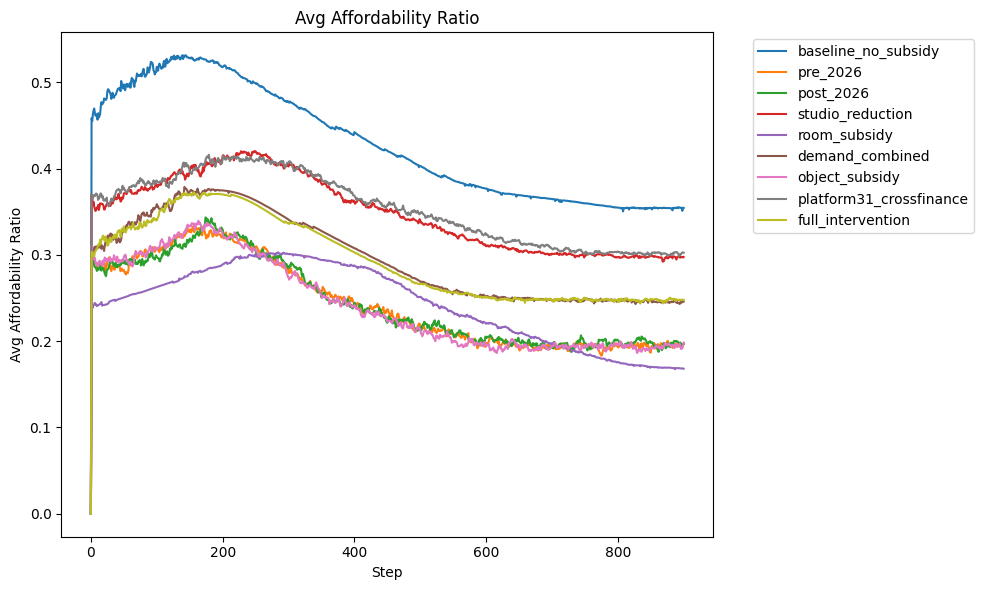

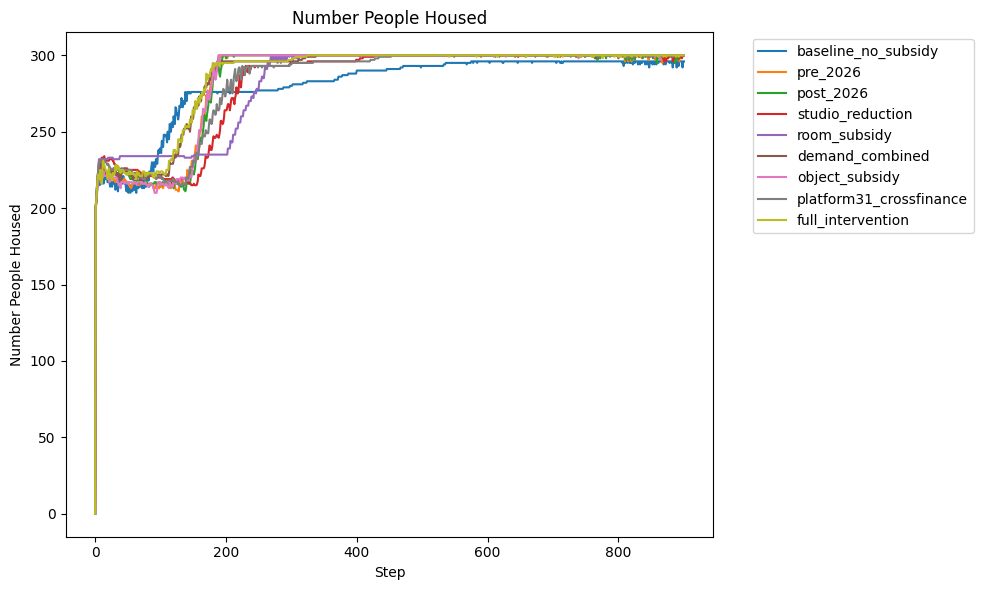

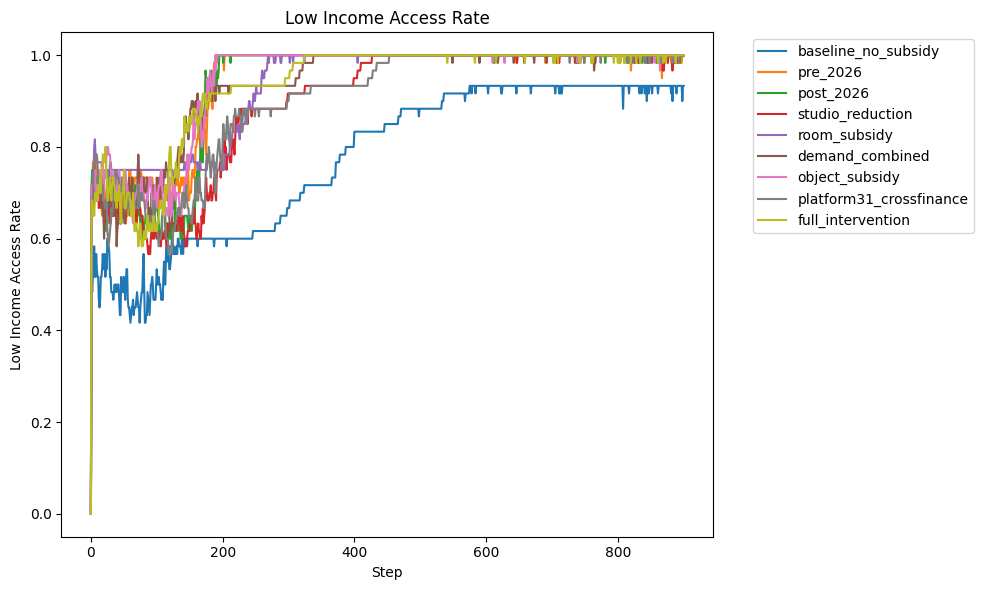

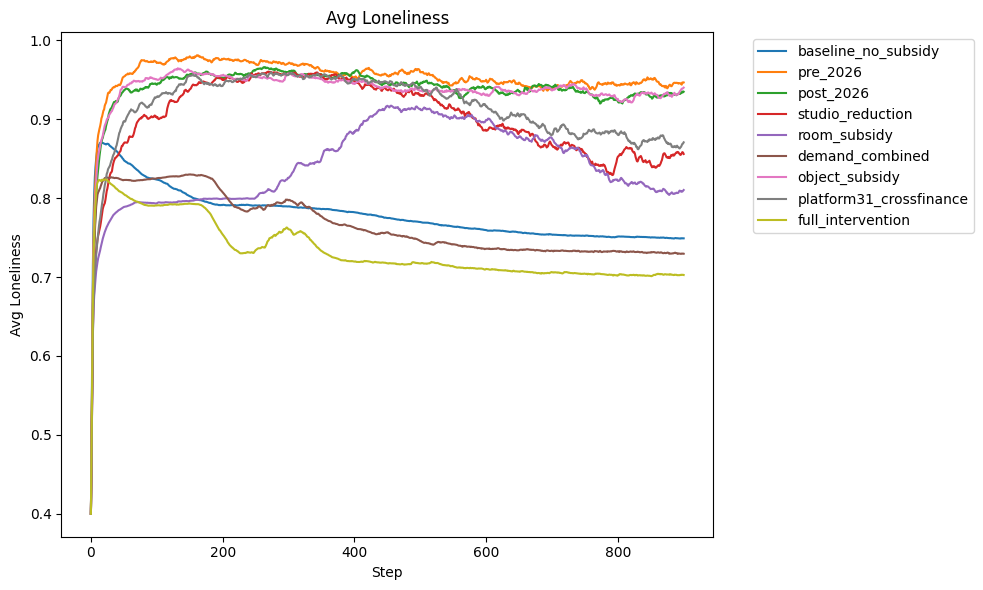

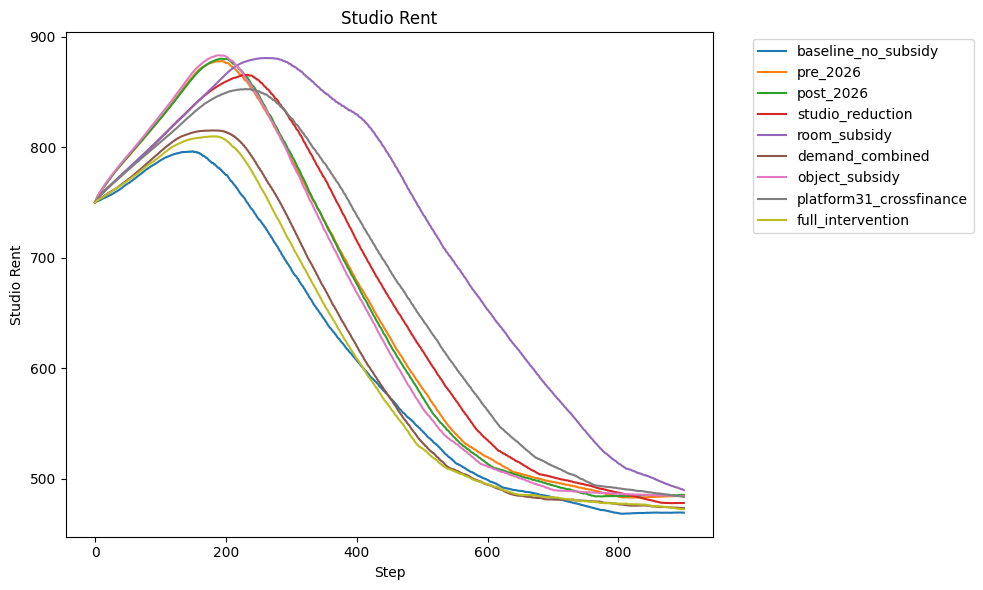

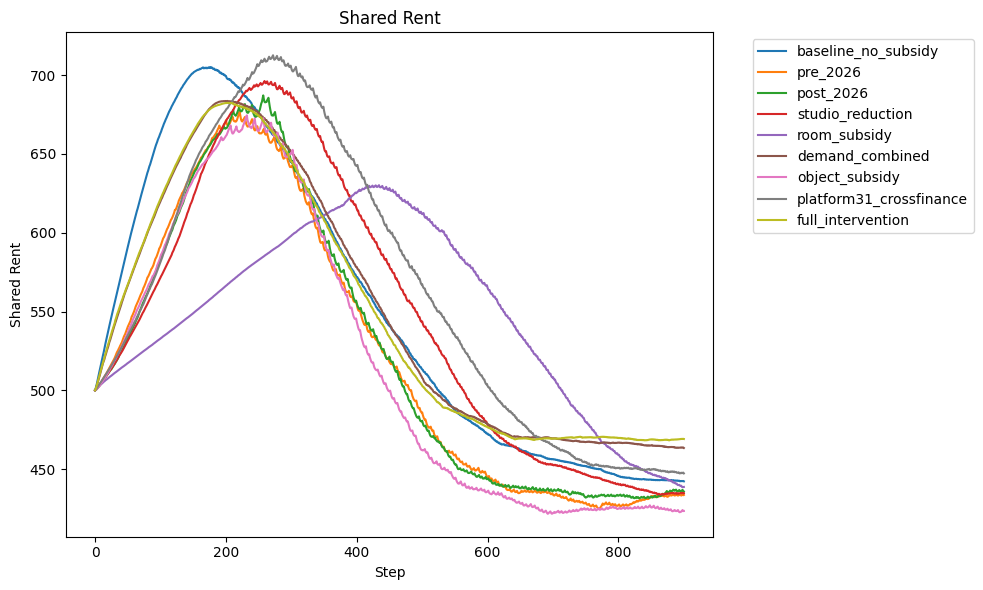

In [198]:
important_outcomes = [
    "avg_affordability_ratio",
    "number_people_housed",
    "low_income_access_rate",
    "avg_loneliness",
    "studio_rent",
    "shared_rent",
]

for outcome in important_outcomes:

    plt.figure(figsize=(10,6))

    for scenario, df in scenario_trajectories.items():

        plt.plot(
            df.index,
            df[outcome],
            label=scenario
        )

    plt.title(outcome.replace("_"," ").title())
    plt.xlabel("Step")
    plt.ylabel(outcome.replace("_"," ").title())

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

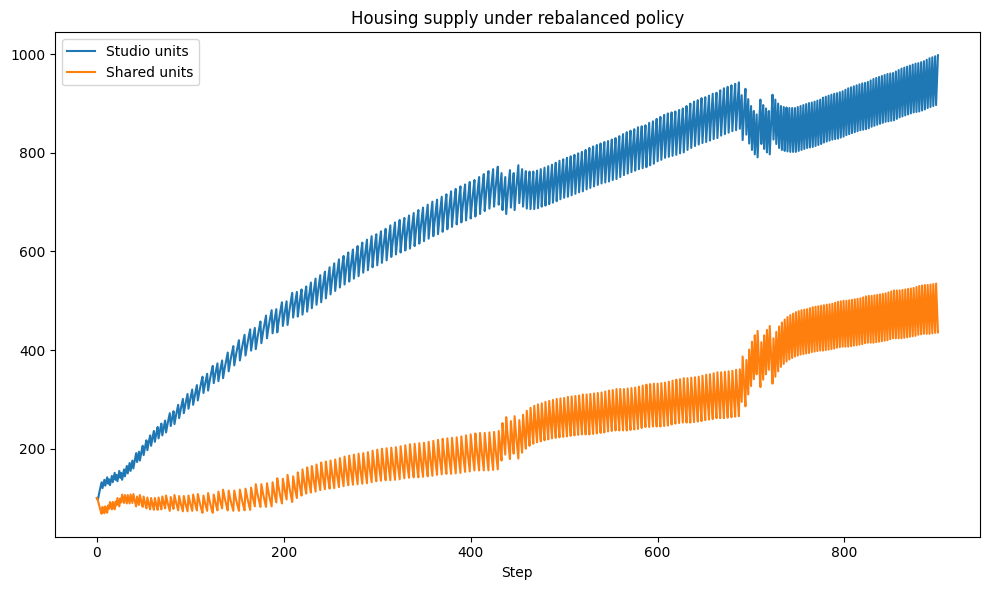

In [199]:
plot_supply_trajectory(model_df, title="Housing supply under rebalanced policy")

In [200]:
comparison = compare_scenarios(steps=900)
# print("\nScenario comparison:")
# print(comparison)
comparison

,scenario,policy_regime,studio_allowance_regime,shared_rent_allowance,ignored_metadata,studio_units,shared_units,studio_rent,shared_rent,effective_studio_cost,...,total_vacancy_rate,avg_waiting_time,match_rate,avg_space_per_person,landlord_revenue_total,landlord_revenue_studio,landlord_revenue_shared,low_income_access_rate,social_contact_opportunities,privacy_lonely_share
0,baseline_no_subsidy,baseline,none,0,"studio_rent_allowance, room_subsidy, object_su...",161.0,126.0,463.938902,443.474461,463.938902,...,0.006969,0.0,0.0,22.067568,134788.324331,79797.491182,54990.833149,0.933333,0.845251,0.324324
1,pre_2026,pre_2026,pre_2026,0,"max_huurtoeslag, huurtoeslag_rent_cap, room_su...",241.0,63.0,484.265578,425.051793,202.520000,...,0.019737,0.0,0.0,23.670000,141904.487671,117676.535491,24227.952179,1.000000,0.403599,0.343333
2,post_2026,post_2026,post_2026,0,"max_huurtoeslag, huurtoeslag_rent_cap, room_su...",246.0,59.0,484.039161,429.382755,202.520000,...,0.016393,0.0,0.0,23.693333,142150.989557,118105.555282,24045.434275,1.000000,0.390967,0.340000
3,studio_reduction,post_2026,post_2026,0,"room_subsidy, object_subsidy_per_room, crossfi...",227.0,84.0,477.211952,440.685858,352.520000,...,0.048232,0.0,0.0,22.946667,139949.289360,101168.933873,38780.355487,1.000000,0.578018,0.356667
4,room_subsidy,post_2026,post_2026,200,"room_subsidy, object_subsidy_per_room, crossfi...",202.0,100.0,475.014327,436.097308,202.520000,...,0.009934,0.0,0.0,22.643333,138573.679166,94527.851093,44045.828073,1.000000,0.708922,0.293333
5,demand_combined,post_2026,post_2026,200,"room_subsidy, object_subsidy_per_room, crossfi...",166.0,144.0,466.925115,460.645495,352.520000,...,0.038710,1.0,1.0,21.593333,139160.710049,71906.467716,67254.242334,1.000000,0.880721,0.260000
6,object_subsidy,post_2026,post_2026,0,"room_subsidy, object_subsidy_per_room, budget_...",233.0,66.0,479.422338,428.155132,202.520000,...,0.006689,2.0,1.0,23.426174,139432.953975,110746.560125,28686.393850,0.983333,0.450950,0.308725
7,platform31_crossfinance,post_2026,post_2026,0,"room_subsidy, object_subsidy_per_room, constru...",220.0,78.0,480.953835,439.203249,352.520000,...,0.013423,0.0,0.0,23.040000,140779.101188,103886.028303,36893.072885,1.000000,0.562053,0.350000
8,full_intervention,post_2026,post_2026,200,"room_subsidy, object_subsidy_per_room, constru...",143.0,152.0,468.366591,462.161585,352.520000,...,0.013559,0.0,0.0,21.546667,139591.636397,71191.721847,68399.914550,1.000000,0.931375,0.270000
